TECHNICAL SOLUTION: SALES PERFORMANCE ANALYSIS

Import CSV Sales Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# Load dataset
df = pd.read_csv("/content/sales_dataset_1000_records - sales_dataset_1000_records.csv")

print("Dataset Loaded Successfully")

# Preview data
"First 5 Rows:"
df.head()


Dataset Loaded Successfully


,Order_ID,Order_Date,Product_Name,Category,Region,Quantity,Unit_Price,Revenue
0,ORD00001,06/06/2024,Product_10,Home,West,7,130.50,913.50
1,ORD00002,02/01/2024,Product_27,Home,Central,3,277.16,831.48
2,ORD00003,22/11/2024,Product_6,Clothing,Central,9,113.64,1022.76
3,ORD00004,17/05/2024,Product_20,Clothing,Central,2,295.88,591.76
4,ORD00005,11/04/2024,Product_22,Sports,East,6,134.32,805.92


Handle Missing Values

In [18]:
print("Missing Values Before Cleaning:")
df.isnull().sum()

Missing Values Before Cleaning:


,0
Order_ID,0
Order_Date,0
Product_Name,0
Category,0
Region,0
Quantity,0
Unit_Price,0
Revenue,0


Clean Missing Values

In [19]:
# Fill numeric columns
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Fill categorical columns
categorical_cols = df.select_dtypes(include='object').columns
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

Verify Cleaning

In [20]:
print("Missing Values After Cleaning:")
df.isnull().sum()

Missing Values After Cleaning:


,0
Order_ID,0
Order_Date,0
Product_Name,0
Category,0
Region,0
Quantity,0
Unit_Price,0
Revenue,0


Convert Date and Create Month Column

In [22]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)
df["Month"] = df["Order_Date"].dt.to_period("M")

print("Month column created successfully")
df[["Order_Date", "Month"]].head()

Month column created successfully


,Order_Date,Month
0,2024-06-06,2024-06
1,2024-01-02,2024-01
2,2024-11-22,2024-11
3,2024-05-17,2024-05
4,2024-04-11,2024-04


Total Revenue

In [23]:
total_revenue = df["Revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 1377633.79


Average Order Value

In [24]:
average_order_value = df["Revenue"].mean()

print("Average Order Value:", average_order_value)

Average Order Value: 1377.63379


Monthly Growth Rate

In [25]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()

In [27]:
monthly_growth_rate = monthly_revenue.pct_change() * 100

print("Monthly Growth Rate (%):")
monthly_growth_rate

Monthly Growth Rate (%):


,Revenue
Month,
2024-01,NaN
2024-02,14.763652
2024-03,-5.425180
2024-04,24.734040
2024-05,-37.650912
2024-06,54.218182
2024-07,-33.052578
2024-08,76.468757
2024-09,-39.096505


Bar Chart (Top 10 Products)

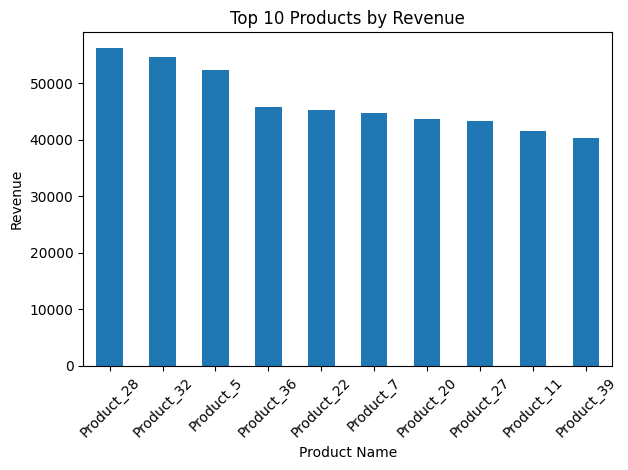

In [28]:
top_products = (
    df.groupby("Product_Name")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
top_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Name")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Line Chart (Monthly Revenue Trend)

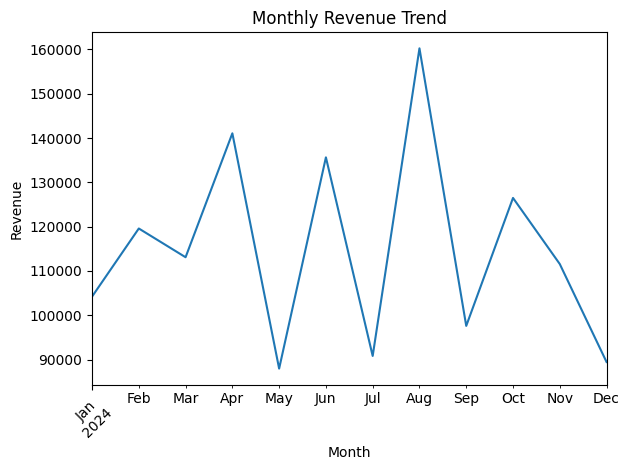

In [29]:
plt.figure()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

HeatMap (Region vs Revenue)

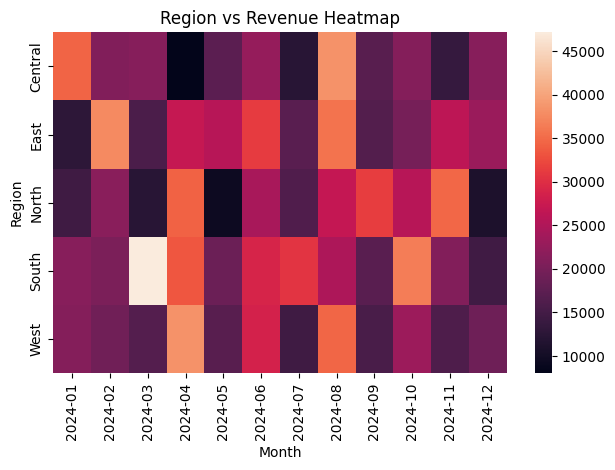

In [32]:
region_revenue = df.pivot_table(
    values="Revenue",
    index="Region",
    columns="Month",
    aggfunc="sum")

plt.figure()
sns.heatmap(region_revenue)
plt.title("Region vs Revenue Heatmap")
plt.tight_layout()
plt.show()